In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import random

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train=pd.read_csv('archive/sign_mnist_test.csv')
test=pd.read_csv('archive/sign_mnist_test.csv')
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [3]:
tungtungtung=tf.convert_to_tensor(train.drop('label',axis=1))
tungtungtung

2026-03-31 09:06:07.574991: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-31 09:06:07.575009: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-31 09:06:07.575011: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-31 09:06:07.575024: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-31 09:06:07.575032: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(7172, 784), dtype=int64, numpy=
array([[149, 149, 150, ..., 112, 120, 107],
       [126, 128, 131, ..., 184, 182, 180],
       [ 85,  88,  92, ..., 225, 224, 222],
       ...,
       [190, 191, 190, ..., 211, 209, 208],
       [201, 205, 208, ...,  67,  70,  63],
       [173, 174, 173, ..., 195, 193, 192]])>

In [4]:
trainlabel= keras.utils.to_categorical(train['label'])
trainlabel.shape

(7172, 25)

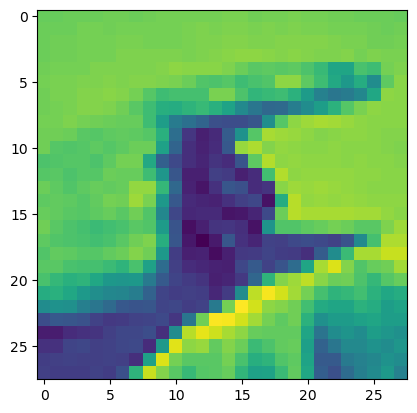

In [5]:
def show_img(ahihidongoc):
    ahihidongoc=tf.reshape(ahihidongoc,[-1,28,28])
    plt.imshow(ahihidongoc[0])
    plt.show()

show_img(tungtungtung)

In [6]:
minmax=MinMaxScaler()
tungtungtung=minmax.fit_transform(tungtungtung)
tungtungtung= tf.reshape(tungtungtung,[-1,28,28,1])
tungtungtung

<tf.Tensor: shape=(7172, 28, 28, 1), dtype=float64, numpy=
array([[[[0.58431373],
         [0.58431373],
         [0.58823529],
         ...,
         [0.58823529],
         [0.58823529],
         [0.58431373]],

        [[0.58823529],
         [0.58823529],
         [0.58823529],
         ...,
         [0.59215686],
         [0.58823529],
         [0.59215686]],

        [[0.58823529],
         [0.59215686],
         [0.59215686],
         ...,
         [0.59215686],
         [0.59215686],
         [0.59607843]],

        ...,

        [[0.27058824],
         [0.27058824],
         [0.30196078],
         ...,
         [0.45490196],
         [0.44313725],
         [0.4627451 ]],

        [[0.29019608],
         [0.29411765],
         [0.29803922],
         ...,
         [0.43137255],
         [0.45490196],
         [0.44313725]],

        [[0.29411765],
         [0.29019608],
         [0.29019608],
         ...,
         [0.43921569],
         [0.47058824],
         [0.41960784]]],


 

In [7]:
X_train, X_val, y_train, y_val=train_test_split(tungtungtung.numpy(), trainlabel, test_size=0.33)
X_train=tf.convert_to_tensor(X_train)
X_val=tf.convert_to_tensor(X_val)

In [8]:
Alexnet=keras.Sequential([
    layers.InputLayer(shape=(28,28,1)),
    layers.Resizing(224,224),
    layers.Conv2D(64,kernel_size=(11,11), strides=(2,2),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(128,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(256,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(128,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(64,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Flatten(),
    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),
    layers.Dense(25,activation='softmax')
])

In [9]:
Alexnet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 55, 55, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    44,306,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │       102,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,066,905 (236.77 MB)

 Trainable params: 62,066,905 (236.77 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
Alexnet.compile(optimizer ='adam', loss ='categorical_crossentropy', metrics =['accuracy'])
Alexnet.fit(X_train, y_train, batch_size=32, epochs=10)

Epoch 1/10


2026-03-31 09:06:08.313074: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


151/151 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - accuracy: 0.0562 - loss: 3.3362
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 37s 245ms/step - accuracy: 0.0593 - loss: 3.1655
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 37s 244ms/step - accuracy: 0.0608 - loss: 3.1620
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.0641 - loss: 3.1687
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.0585 - loss: 3.1619
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 38s 250ms/step - accuracy: 0.0612 - loss: 3.1696
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 37s 246ms/step - accuracy: 0.0624 - loss: 3.1698
Epoch 8/10
104/151 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.0573 - loss: 3.1876

KeyboardInterrupt: 